### Setup and Functions

In [1]:
import xarray as xr
from astropy.time import Time
from sunpy.time import parse_time
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from astropy import constants as const

solar_radius = const.R_sun.value 
au = const.au.value  # Astronomical Unit in meters
k = const.k_B.value  # Boltzmann constant in J/K
c = const.c.value  # Speed of light in m/s
h = const.h.value  # Planck's constant in J*s
sigma = const.sigma_sb.value  # 5.6704e-8 W/m²/K⁴



In [2]:
ds = xr.open_dataset("data/sorce_sim_L3_c24h_0240nm_2413nm_20030414_20200225.nc")

t = Time(ds["time"].values, format="jd")
ds["time"] = ("time", t.to_datetime())

df = ds.to_dataframe().reset_index('wavelength')
print(df.head())

                     wavelength  irradiance  uncertainty  quality
time                                                             
2003-04-14 12:00:00  240.020004    0.041338     0.000399       64
2003-04-14 12:00:00  240.110001    0.042611     0.000403       64
2003-04-14 12:00:00  240.190002    0.043288     0.000405       64
2003-04-14 12:00:00  240.279999    0.042863     0.000409       64
2003-04-14 12:00:00  240.369995    0.041678     0.000412       64


# Parcial 1

## Context of Data

In [3]:
ds.attrs

{'title': 'SORCE-SIM SSI (Solar Spectral Irradiance) V27',
 'version': 'V01.01',
 'file_version': 'V01.05',
 'time_cadence': '24 hour',
 'institution': 'Laboratory for Atmospheric and Space Physics, University of Colorado - Boulder',
 'date_created': 'Wed Apr  7 03:40:08 2021 UTC',
 'time_coverage_start_jd': '2452744.000000',
 'time_coverage_end_jd': '2458905.000000',
 'contributor_name': 'Steven Penton (steven.penton@lasp.colorado.edu)',
 'history': 'This file was created after the conclusion of the SORCE mission. This is data version 01 of the SIM data. The version of this file is V01.05 . File versions greater than V01.04 use double precision for irradiance.',
 'DOI': 'https://doi.org/10.5067/LDDKZ3PXZZ5G'}

In [4]:
start_time = parse_time(ds.attrs['time_coverage_start_jd'],format='jd')
end_time = parse_time(ds.attrs['time_coverage_end_jd'],format='jd')

print(f"Data covers from {start_time.iso} to {end_time.iso}")

Data covers from 2003-04-14 12:00:00.000 to 2020-02-25 12:00:00.000


The dataset contains measurements at 24-hour intervals. Accordingly, October 27, 2006 is selected as the date of analysis.

In [5]:
selected_time = '2006-10-27 12:00:00'
selected_time_jd = Time(selected_time).jd
print('julian day:', selected_time_jd)

julian day: 2454036.0


In [6]:
data = df.loc['2006-10-27 12:00:00'].reset_index(drop=True).copy()
data.describe()

,wavelength,irradiance,uncertainty,quality
count,1235.000000,1235.000000,1235.000000,1235.000000
mean,552.826599,0.752969,0.000625,0.017814
std,464.644928,0.636563,0.000628,0.187986
min,240.020004,0.035762,0.000062,0.000000
25%,276.305008,0.189553,0.000231,0.000000
50%,347.559998,0.605870,0.000339,0.000000
75%,581.569977,1.127360,0.000876,0.000000
max,2412.340088,2.104573,0.003037,2.000000


## theory

**Monochromatic flux** (called *irradiance* by the SORCE mission) is the energy per unit area 
per unit wavelength:

$$[F_\lambda] = \left[\frac{\text{W}}{\text{m}^2 \text{ nm}}\right]$$

**Specific intensity** $I_\lambda$ is the flux per steradian:

$$I_\lambda = \frac{F_\lambda}{\Omega_\odot} \quad \left[\frac{\text{W}}{\text{m}^2 \text{ sr nm}}\right]$$

where $\Omega_\odot = 2\pi (1-\cos \theta_{\odot})$ is the solid angle of the Sun for a given date.

**Planck's law** gives the specific intensity of a blackbody at temperature $T$:

$$B_\lambda(T) = \frac{2hc^2}{\lambda^5} \frac{1}{e^{hc/\lambda k_B T} - 1} 
\quad \left[\frac{\text{W}}{\text{m}^2 \text{ sr nm}}\right]$$

h, b, k are given by codata 2014 [3] used by stropy. Fitting $B_\lambda(T)$ to the observed 
$I_\lambda$ gives the **color temperature** $T_\text{color}$ of the Sun.

**Stefan-Boltzmann law** gives the total flux emitted at the solar surface.
Scaling the measured flux to the Sun's surface via the inverse square law:

$$F_\odot = F_{\text{int}} \left(\frac{d_\odot}{R_\odot}\right)^2$$

were $d_odot$ is the distance from the observer to the sun and $R_\odot$ is the solar radius, and applying Stefan-Boltzmann:

$$F_\odot = \sigma T_{\text{eff}}^4 \implies T_{\text{eff}} = \left(\frac{F_\odot}{\sigma}\right)^{1/4}$$

where $\sigma = 5.6704\times10^{-8}$ W m$^{-2}$ K$^{-4}$. The resulting $T_{\text{eff}}$ 
is the **effective temperature** of the Sun.

In [7]:
ds['irradiance'].attrs


{'units': 'W m-2 nm-1',
 'standard_name': 'Solar Spectral Irradiance (SSI)',
 'long_name': 'Solar Spectral Irradiace (W m-2 nm-1)'}

## 1. Grafique la función espectral flujo monocromático versus longitud de onda.

In [ ]:
plt.errorbar(data['wavelength'], data['irradiance'], color='blue', alpha=0.7, yerr=data['uncertainty'])
plt.xlabel(r'Wavelength ($nm$)')
plt.ylabel(r'$F_\lambda$ ($W/m²/nm$)')
plt.title('Solar espectrum monochromatic flux at 2006-10-27')
plt.savefig('figures/actividad1_flujo.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.show()

Note that the observed spectral distribution closely resembles a Planck blackbody curve, and that the reported measurement uncertainty is negligible.

## 2. Para la fecha dada, averigüe la distancia geocéntrica del Sol, así como el diámetro angular aparente del mismo, y calcule el ángulo sólido para la fecha.

According to Stellarium, the solar parameters for October 27, 2006 are as follows:

- Apparent solar radius: 0°32′11.22″
- Earth–Sun distance: 148,672,000 km

Additional reference values from Stellarium:

- Astronomical unit: 149,597,870.7 km (mean Earth–Sun distance)
- Solar diameter: 1,392,000 km

The positional effects of the SORCE satellite orbit are negligible, as the spacecraft orbits at an altitude of 569 km with an inclination of 40.0° from Earth's rotational axis and an orbital period of approximately 90 minutes. Any residual variation is averaged out by the 24-hour integration cadence already applied by the mission.

In [9]:
diameter_arcsec = 32 * 60 + 11.41
alpha_arcsec = diameter_arcsec / 2.0
alpha_rad = alpha_arcsec / 206265.0
Omega_sun = 2 * np.pi * (1 - np.cos(alpha_rad))



Omega_sun_calculated = np.pi * (solar_radius / au)**2

print(f"Solid angle (from angular diameter): {Omega_sun:.3e} sr")
print(f"Mean Solid angle (from solar radius and distance(1uA)): {Omega_sun_calculated:.3e} sr")


Solid angle (from angular diameter): 6.886e-05 sr
Mean Solid angle (from solar radius and distance(1uA)): 6.794e-05 sr


Both values are in close agreement, confirming the consistency of the computation. Hereafter, the solid angle derived from the apparent angular diameter will be used, as it is more accurate for the specific observation date.

## 3. Represente en forma gráfica el espectro en términos de la intensidad específica versus longitud de onda.

In [10]:
data['specific_intensity'] = data['irradiance'] / Omega_sun
data['specific_intensity_error'] = data['uncertainty'] / Omega_sun

In [11]:
from utilities import plot_data

In [ ]:
plot_data(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    yerr=None,
    xlabel=r"Wavelength ($nm$)",
    ylabel=r"$I_\lambda$ ($W/m²/nm/sr$)",
    title='Solar Spectrum Specific Intensity at 2006-10-27',
    labels=['Data'],
    colors=['red'],
    title_fontsize=16,
    axis_label_fontsize=14,
    tick_fontsize=12,
    legend_fontsize=11,
    figure_dpi=100,
    figure_size=(10, 7),
    grid_alpha=0.2,
    legend_loc='best',
    savepath='figures/actividad3_intensidad.png'
);

## 4. Ajuste una curva de intensidad de Planck, la mejor posible, al espectro anterior (punto 3). La curva de Planck debe tener su máximo lo más cercano al máximo real, debe coincidir en al menos un punto antes del máximo y otro después del máximo. La temperatura de esta curva teórica se denomina la "temperatura de color" del astro, en nuestro caso el Sol.

In [13]:
from utilities import blackbody_plot_with_temps


''

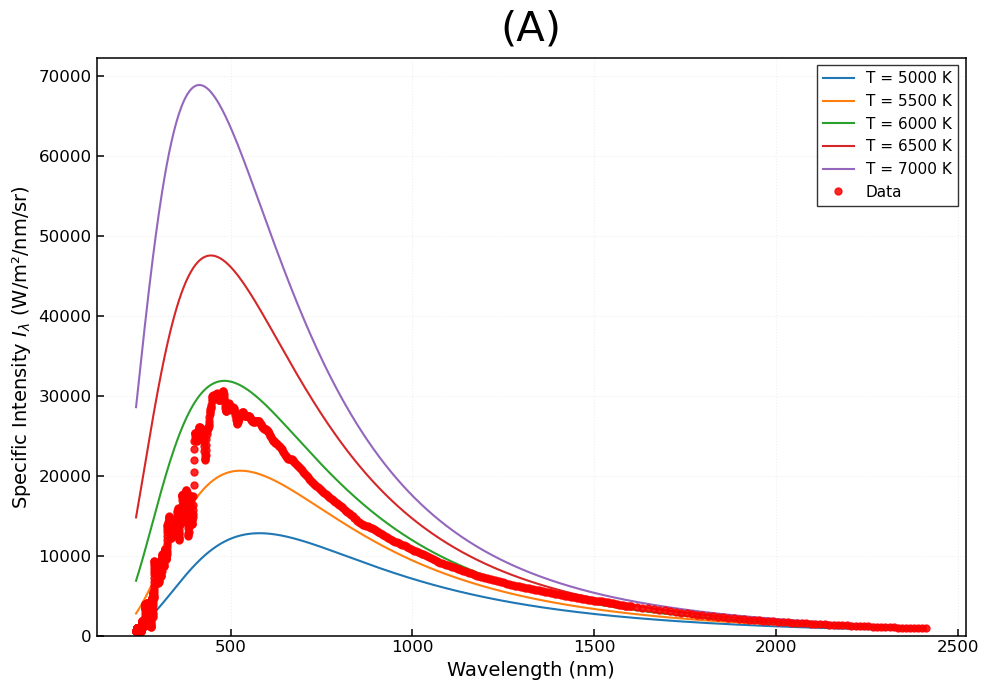

In [ ]:
fig_1 = blackbody_plot_with_temps(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    temp_params=[5000, 7000, 5],
    yerr=None,
    xlabel="Wavelength (nm)",
    ylabel=r"Specific Intensity $I_\lambda$ (W/m²/nm/sr)",
    title='(A)',
    labels=['Data'],
    colors=['red'],
    title_fontsize=30,
    show=False
);

/home/thomas/Desktop/Solar_espectrum_analisis/utilities.py:343: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


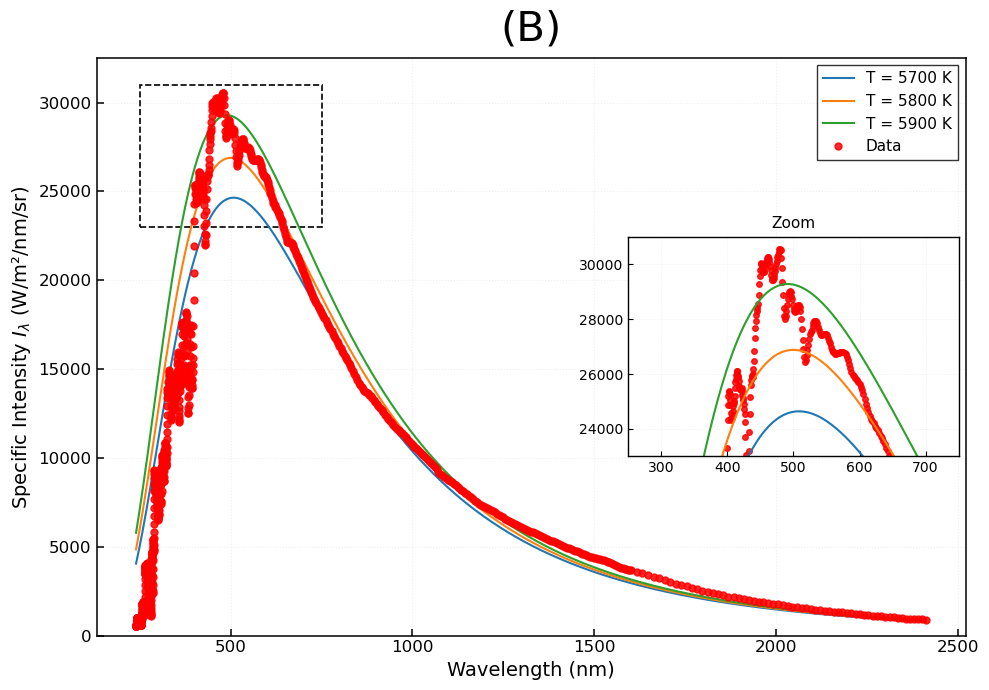

In [15]:
fig_2 = blackbody_plot_with_temps(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    temp_params=[5700, 5900, 3],
    yerr=None,
    xlabel="Wavelength (nm)",
    ylabel=r"Specific Intensity $I_\lambda$ (W/m²/nm/sr)",
    title='(B)',
    labels=['Data'],
    colors=['red'],
    show_box_zoom=True,
    box=[(250,23000),( 750,31000)],
    legend_loc='upper right',
    title_fontsize=30

);

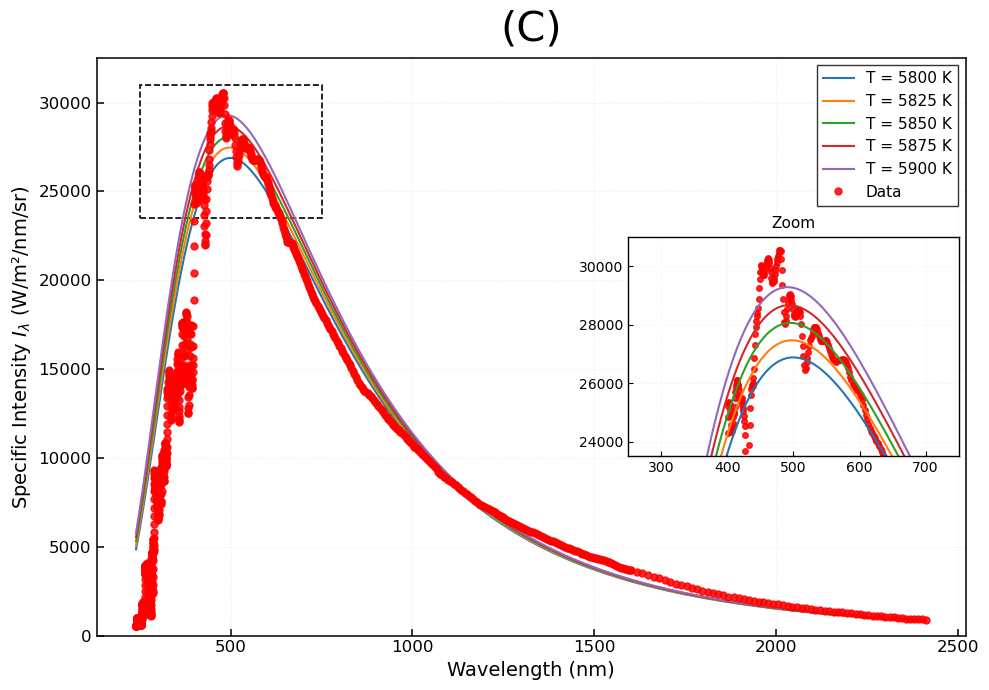

In [16]:
fig_3 = blackbody_plot_with_temps(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    temp_params=[5800, 5900, 5],
    yerr=None,
    xlabel="Wavelength (nm)",
    ylabel=r"Specific Intensity $I_\lambda$ (W/m²/nm/sr)",
    title='(C)',
    labels=['Data'],
    colors=['red'],
    show_box_zoom=True,
    box=[(250,23500),( 750,31000)],
    title_fontsize=30
);

$T = 5875\ \mathrm{K}$

The 5900 K curve more closely approaches the observed spectral maximum; however, curves at temperatures above 5900 K fail to intersect any data points prior to the maximum, violating one of the required fitting criteria.

In [17]:
from utilities import blackbody_temperature_comparison_with_errors


--- Results for Data ---
Estimated temperature: 5875 ± 1 K
R²:                    0.691245


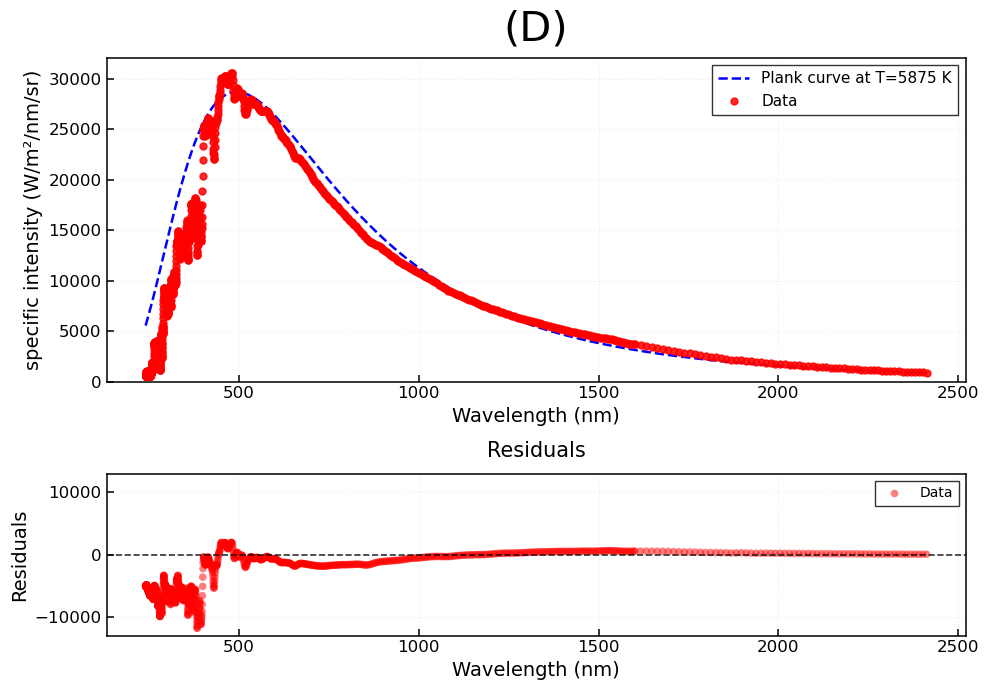

In [18]:
_, fig_4 = blackbody_temperature_comparison_with_errors(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    yerr=None,
    xlabel="Wavelength (nm)",
    ylabel=r"specific intensity (W/m²/nm/sr)",
    title='(D)',
    labels=['Data'],
    colors=['red'],
    temperature=5875,
    title_fontsize=30
)

In [ ]:
figs = [fig_1, fig_2, fig_3, fig_4]

fig_grid, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
axes = axes.ravel()

for i, (ax, fig) in enumerate(zip(axes, figs), start=1):
    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())
    ax.imshow(img)
    ax.axis('off')

for ax in axes[len(figs):]:
    ax.axis('off')

fig_grid.suptitle('Solar Spectrum Analysis with Blackbody Fits', fontsize=24)
fig_grid.tight_layout()
fig_grid.savefig('figures/actividad4_planck_fit.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

Based on the preceding figures, the color temperature of the Sun is determined to be $T = 5875\ \mathrm{K}$. Considering that the Planck curve should approximate the observed spectral maximum, an initial estimate would suggest a value exceeding $5900\ \mathrm{K}$, as shown in panel (B); however, careful inspection reveals that curves at those temperatures do not intersect any data points prior to the spectral maximum, which is an additional fitting requirement. With this constraint in mind, the optimal temperature is the one that approaches the observed maximum as closely as possible while still crossing at least one data point before it. This condition is satisfied by $T = 5875\ \mathrm{K}$, as illustrated in panel (C). Furthermore, panel (D) demonstrates that a Planck fit at this single temperature provides a reasonably good agreement with the observed spectrum, with residuals likely attributable to the noise inherent in the SORCE/SIM measurements.

## 5. Con el dato espectral en flujo monocromático, integrando sobre todo el rango espectral medido, obtiene un valor de flujo integrado. Compare dicho valor con el reportado para la fecha por el instrumento SORCE/TIM (Total Irradiance Monitor). Como el flujo integrado decae con el inverso del cuadrado de la distancia, para la fecha dada, corrija por la distancia teniendo en cuenta el radio solar y la distancia Sol-Tierra de la fecha, para obtener así el flujo integral integrado de la radiación emitida en la superficie solar. Con dicho valor, calcule la temperatura efectiva del Sol.

In [20]:
from scipy.integrate import trapezoid

x = data['wavelength'].values
y = data['irradiance'].values

real_distance = 0.994 #AU

computed_tsi = trapezoid(y, x)
computed_tsi = computed_tsi * (1/real_distance**2)
computed_tsi


np.float64(1337.8711095974197)

The integrated flux, or total irradiance, is computed using the trapezoidal rule, which is appropriate given the discrete and noisy nature of the data. The result is corrected for the Earth–Sun distance on the date of analysis ($r = 0.994\ \mathrm{AU}$), accounting for the inverse-square law $F \propto r^{-2}$.

In [21]:
tsi = pd.read_csv(
    "data/sorce_tsi_L3_c24h_latest.txt",
    comment=';',
    sep=r'\s+',
    header=None,
    names=[
        'date_yyyymmdd', 'date_jdn', 'avg_date_jdn', 'std_date',
        'tsi_1au', 'accuracy_1au', 'precision_1au', 'solar_std_1au', 'uncertainty_1au',
        'tsi_earth', 'accuracy_earth', 'precision_earth', 'solar_std_earth', 'uncertainty_earth',
        'provisional_flag'
    ]
)

reported_value_tsi =  tsi.loc[tsi['date_jdn'] == selected_time_jd]['tsi_1au'].values[0]

tsi.loc[tsi['date_jdn'] == selected_time_jd]



,date_yyyymmdd,date_jdn,avg_date_jdn,std_date,tsi_1au,accuracy_1au,precision_1au,solar_std_1au,uncertainty_1au,tsi_earth,accuracy_earth,precision_earth,solar_std_earth,uncertainty_earth,provisional_flag
1340,20061027.5,2454036.0,2.454036e+06,0.3,1360.8207,0.479,0.0068,0.06098,0.4829,1377.7897,0.485,0.0068,0.2701,0.5551,0


In [23]:
print(f'normalized to 1AU')
print(f"Computed integrated Flux from spectrum: {computed_tsi:.1f} W/m²")
print(f"Reported integrated Flux from SORCE: {reported_value_tsi:.1f} W/m²")

normalized to 1AU
Computed integrated Flux from spectrum: 1337.9 W/m²
Reported integrated Flux from SORCE: 1360.8 W/m²


The integrated flux computed via the trapezoidal rule is in close agreement with the value officially reported by the SORCE/TIM mission. The small discrepancy arises because the latter incorporates additional wavelength ranges from complementary instruments; however, since the difference is small, no further refinement is required.

In [ ]:
flux = computed_tsi * ((au**2)/(solar_radius**2))

computed_temperature = np.power(flux/sigma,0.25)
print(f"Computed effective temperature: {computed_temperature:.1f} K")

Computed effective temperature: 5747.1 K


The computed effective temperature is $T = 5747.1\ \mathrm{K}$, in reasonable agreement with the color temperature of $T = 5875\ \mathrm{K}$ obtained previously. Despite both methods relying on the same theoretical framework, some discrepancy is expected, as different estimation techniques exhibit varying degrees of resilience to observational noise. According to the reference value reported in Springer [2], the accepted effective temperature of the Sun is $T = 5778\ \mathrm{K}$; consequently, the estimate derived from the integrated flux proves to be the more accurate of the two, likely because trapezoidal integration is more robust to spectral noise than an empirical fit to the Planck curve. Nevertheless, both methods yield results in close agreement with the accepted value.

# bibliography

[1] J. Harder (2020), SORCE SIM Level 3 Solar Spectral Irradiance Daily Means V027, Greenbelt, MD, USA, Goddard Earth Sciences Data and Information Services Center (GES DISC), Accessed: [Accessed: Apr. 18, 2026], 10.5067/LDDKZ3PXZZ5G

[2] The Sun: An Introduction | Springer Nature Link. Springer, p. 10. [En línea]. Disponible: https://link.springer.com/book/10.1007/978-3-642-56042-2. [Accessed: Apr. 19, 2026].

[3] P. J. Mohr, D. B. Newell, y B. N. Taylor, “CODATA recommended values of the fundamental physical constants: 2014,” Rev. Mod. Phys., vol. 88, n.º 3, p. 035009, sep. 2016. doi: 10.1103/RevModPhys.88.035009.